# Imports

In [1]:
# Add the directory where starships' directory is located
from sys import path
path.append('/home/mathisb/Github/starships')

# Add the directory containing the input data (opacity, abundance and stellar specs files)
import os
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import starships.homemade as hm
from starships import spectrum as spectrum
from starships.mask_tools import interp1d_masked

interp1d_masked.iprint=False
import warnings

import astropy.constants as const
import astropy.units as u
import numpy as np
from findiff import FinDiff
import starships.planet_obs as pl_obs
import starships.plotting_fcts as pf
from starships.planet_obs import Observations

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# Read spectra and useful quantities

## Note: Better to use the scratch space to save the reductions.
You have infinite space, but the files are deleted if untouched for 2 months. It allows to save as many reductions as desired. Once the correct reduction parameters are set, you can move them into your home directory.

In [3]:
#--------------------------------------------------------------------------------------------
# Planet, night, reduction and instrument
pl_name = 'TRAPPIST-1 b'
visit_name = '2021-10-24'
reduction = 'vnoPC01'
instrument = "SPIRou"

#--------------------------------------------------------------------------------------------

# Directory where to save reductions
# > use scratch if available, use home if not
try:
    out_dir = Path(os.environ['SCRATCH'])
except KeyError:
    out_dir = Path.home()

# Output reductions in dedicated directory
pl_name_fname = ''.join(pl_name.split())
out_dir /= Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduction}')
# Make sure the  directory exists
out_dir.mkdir(parents=True, exist_ok=True)


In [4]:
# Relevant directories

# Where to find the observations (data)?
obs_dir = f"/home/mathisb/Github/HRS_data/{instrument}/TRAPPIST-1/{visit_name}/"  # for TRAPPIST-1 SPIRou data

# Where to save figures?
path_fig = Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/Figures')

In [5]:
# Create text files with all the e (e2ds) and t (tcorr) data files listed

# ed2s
# with open(obs_dir + 'list_e2ds.txt', 'a+') as e_txt:
#     for i in sorted(os.listdir(obs_dir)):
#         if i[-6:] == "e.fits":
#             e_txt.write(i + '\n')

# tcorr
# with open(obs_dir + 'list_tcorr.txt', 'a+') as t_txt:
#     for i in sorted(os.listdir(obs_dir)):
#         if i[-6:] == "t.fits":
#             t_txt.write(i + '\n')


In [6]:
# All the observations must be listed in files.
# We need the e2ds and the telluric corrected spectra.

list_filenames = {'list_e2ds': 'list_e2ds.txt',
                  'list_tcorr': 'list_tcorr.txt'}

In [7]:
# SPECIFY PARAMETERS OF THE PLANET
# If not specified, the default parameters from exofile are taken.

# Most parameters from trappist.one website
ap     = 0.01150*u.au       # semi-major axis of planet
R_star = 0.121*u.R_sun      # radius of star
R_pl   = 1.127*u.R_earth    # radius of planet
M_star = 0.089*const.M_sun  # mass of star
e      = 0                  # eccentricity
w      = 4.712389*u.rad     # argument of periapsis (equal to 270 degrees)

#-----------------------------------------------------------#


# Mid-transit time (BJD) of each TRAPPIST-1 b visit (calculated from Agol et al. 2021)
mid_tr_dict = {"2019-06-14": 2458649.07123219 * u.d,
               "2019-09-25": 2458751.81121859 * u.d,
               "2020-05-31": 2459001.10675595 * u.d,
               "2020-08-04": 2459066.07480784 * u.d,
               "2020-09-08": 2459100.82490157 * u.d,
               "2020-09-20": 2459112.91190288 * u.d,
               "2020-09-26": 2459118.95517189 * u.d,
               "2020-09-29": 2459121.97749932 * u.d,
               "2021-10-21": 2459508.7625026763 * u.d,
               "2021-10-24": 2459511.7847065893 * u.d,
               "2021-10-27": 2459514.8059848337 * u.d,
                }

mid_tr = mid_tr_dict[visit_name]


obs = Observations(name=pl_name, 
                   pl_kwargs = {'M_star': M_star, 
                                'R_star': R_star,
                                'ap': ap,
                                'R_pl': R_pl,
                                'mid_tr': mid_tr,
                                'excent': e,
                                'w': w})

# Get the data
obs.fetch_data(obs_dir, **list_filenames, CADC=True)
p = obs.planet

# Verify that the info is good
print("\n" + "M_star:", M_star, "\t", "R_star:", R_star, "\nap:", ap, "\t", "R_pl:", R_pl,  "\t", 
      "mid_tr:", mid_tr, "\ne:", e,  "\t", "w:", w)

INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.769684784921265e+29 kg
INFO:starships.planet_obs:It became [1.76968478e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.121 solRad
INFO:starships.planet_obs:It became [84179700.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.0115 AU
INFO:starships.planet_obs:It became [1.72037551e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.127 earthRad
INFO:starships.planet_obs:It became [7188118.7] m
INFO:starships.planet_obs:Changing mid_tr from [2457322.514193] d to 2459511.7847065893 d
INFO:starships.planet_obs:It became [2459511.78470659] d
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [10.5917051] rad to 4.712389 rad
INFO:starships.planet_obs:It became [4.712389] rad
INFO:starships.


M_star: 1.769684784921265e+29 kg 	 R_star: 0.121 solRad 
ap: 0.0115 AU 	 R_pl: 1.127 earthRad 	 mid_tr: 2459511.7847065893 d 
e: 0 	 w: 4.712389 rad


# Build transmission spectrum

In [9]:
"""
param_all: Reduction parameters
telluric fraction to mask (usually varied between 0.2 and 0.5), 
limits for the wings, 
width of the smoothing kernel for the low pass filter (fixed at 51), 
useless param, 
width of the gaussian kernel for low pass filter (fixed at 5),
PCs (nb of principal components) to remove,
sigma clips params (fixed at 5.0)
"""

#--------------------------------------------------------------------------------------------
# PARAMETERS TO CHANGE

RVsys = [-52.003101]  # change to RV of star system
kind_trans = 'transmission'  # emission or transmission
coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'

tellu_frac = 0.40  # telluric fraction to mask (usually varied between 0.2 and 0.5)
mask_wings = 0.97  # fraction of wings of deep tellurics that is masked

#--------------------------------------------------------------------------------------------

# PCA

PCA_max = 0  # the code will test all the nPC up to this number, and choose the nPC where the Δσ metric plateaus
PCs = np.arange(1, PCA_max + 1)

#--------------------------------------------------------------------------------------------


cbp = True  # correct bad pixels

iout_all = ['all']
polynome = [False] 
do_tr = [1]
transit_tags = [None]  # use if want to remove spectra

kwargs_gen_tr = {
    'coeffs' : coeffs,
    'ld_model' : ld_model,
    'do_tr' : do_tr,
    'kind_trans' : kind_trans,
    'polynome' : polynome,
    'cbp': cbp }

kwargs_build_ts = {
    'clip_ratio' : 6,
    'clip_ts' : 6,
    'unberv_it' : True }


tr_spectra = np.empty((len(PCs),1), dtype=object)

for n_pc in PCs:
    
    # Get reduced spectrum for n_pc
    params_all=[[tellu_frac, mask_wings, 51, 41, 5, n_pc, 5.0, 5.0, 5.0, 5.0]]
    list_tr = pl_obs.generate_all_transits(obs, transit_tags, RVsys, params_all, iout_all, **kwargs_gen_tr, **kwargs_build_ts)
    
    # Save transmission spectra for use in next cell
    if n_pc == PCs[0]:  # if this is the first iteration
        no_PCA_spectrum = list_tr["1"].spec_trans
    tr_spectra[n_pc - 1][0] = list_tr["1"].final
    
    # Save sequence with all reduction steps
    out_filename = f'sequence_{n_pc}-pc_mask_wings{mask_wings*100:n}'
    pl_obs.save_single_sequences(out_filename, list_tr['1'], path=out_dir, filename_end=visit_name, save_all=True)
    
    # Save sequence with only the info needed for a retrieval (to compute log likelihood).
    out_filename = f'retrieval_input_{n_pc}-pc_mask_wings{mask_wings*100:n}'
    pl_obs.save_sequences(out_filename, list_tr, do_tr, path=out_dir)
    

([5.288093411801997, 5.501519467826659, 5.452711793548092, 4.760005269202172, 4.677769869355209, 4.883728023135374, 4.7829845925603225, 4.919643587068462, 4.739452532310887, 4.802733520307832, 5.240272740983751, 5.240735565607319, 4.657069709098198, 5.031921756696264, 5.817672846735637, 5.265733152859419],)
[2459511.78470659] d
Transmission
Masking high variance pixels (quick fix for OH lines). 
flux_norm all nan : False
Shifting everything in the stellar ref. frame and normalizing by the median 
Spectra 
 Unberv : 48 - 15  
Telluriques 
 Unberv : 48 - 15  
flux_Sref all nan : False
Masking deep tellurics. 
flux_masked all nan : False
Building the master out #1 
ratio_filt has values <= 0.75!
flux_norm_mo all nan : False
master_out all nan : False
Building the transmission spectrum #1 
spec-trans all nan : False
Removing the static noise with PCA and sigma cliping 
(16, 49, 4088)
spec_trans all nan : False
clean_ts all nan : False
Removing the mean 
Removing the remaining high variance

## Choose the right nPC

In [11]:
# Calculate the metrics for PCA evaluation (Birkby poster)
# ( to use only out of transit expositions, replace [:,j,:] by [list_tr["1"].iOut,j,:] )

list_metrics = []
nb_orders = np.shape(no_PCA_spectrum)[1]

for n_pc in PCs:
    # Calculate σ of previous n_pc
    if n_pc == PCs[0]:  # if this is the first iteration, sig_i_minus1 is the std dev of the non-PCA-corrected transmission spectrum
        std_dev_order = []
        
        # Calculate std dev of reduced spectrum in each order, then take the mean of these std dev
        for j in range(nb_orders):
            std_dev_order.append(np.std(no_PCA_spectrum[:,j,:]))

        sig_i_minus1 = np.nanmean(std_dev_order)  # nanmean because there are some orders that are completely masked
    
    else:
        sig_i_minus1 = sig_i  # std dev of the previous loop
    
    
    # Calculate σ of current n_pc
    std_dev_order = []
    tr_spectrum = tr_spectra[n_pc - 1][0]

    # Calculate std dev of reduced spectrum in each order, then take the mean of these std dev
    for j in range(nb_orders):  # tr_spectrum is the transmission spectrum after PCA
        std_dev_order.append(np.std(tr_spectrum[:,j,:]))

    sig_i = np.nanmean(std_dev_order)  # nanmean because there are some orders that are completely masked
    
    
    # Calculate metric
    delta_sig = (sig_i_minus1 - sig_i) / sig_i_minus1
    list_metrics.append(delta_sig)
        

In [12]:
# Choose a threshold for the slope of the metric
# When the slope is under that threshold, we consider that the metric plateaus
thresh = 0.1
#-----------------------------------------------

metrics = np.array(list_metrics)

deriv_func = FinDiff(0,1)
deriv_metrics = deriv_func(metrics)

plt.figure(figsize=(5,3))
plt.plot(PCs, deriv_metrics, marker="o", color="slategrey")
plt.axhline(-thresh, color="r", label="Threshold")

plt.xlabel("nPC")
plt.ylabel("Derivative of the metric")
plt.legend()
plt.show()

IndexError: Shift slice out of bounds

Threshold: 0.1
The nPC where the metric plateaus is: 2


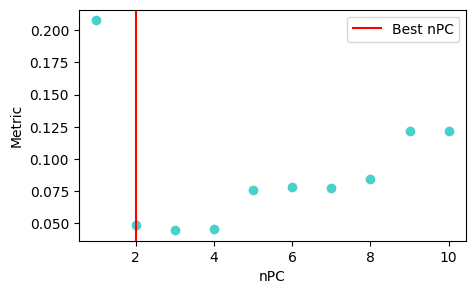

In [25]:
print("Threshold:", thresh)

for m in deriv_metrics:
    if m < thresh and m > -thresh:
        best_nPC = np.where(deriv_metrics == m)[0][0] + 1
        print("The nPC where the metric plateaus is:", best_nPC)
        break

plt.figure(figsize=(5,3))
plt.scatter(PCs, metrics, color="mediumturquoise")
plt.axvline(best_nPC, color="r", label="Best nPC")

plt.xlabel("nPC")
plt.ylabel("Metric")
plt.legend()
plt.show()

## Choose the right nPC (per order)

In [56]:
# Calculate the metrics for PCA evaluation (Birkby poster)
# ( to use only out of transit expositions, replace [:,j,:] by [list_tr["1"].iOut,j,:] )

metrics = np.empty((len(PCs),1), dtype=object)
nb_orders = np.shape(no_PCA_spectrum)[1]

for n_pc in PCs:
    # Calculate σ of previous n_pc
    if n_pc == PCs[0]:  # if this is the first iteration, sig_i_minus1 is the std dev of the non-PCA-corrected transmission spectrum
        std_dev_order = []
        
        # Calculate std dev of reduced spectrum in each order
        for j in range(nb_orders):
            std_dev_order.append(np.std(no_PCA_spectrum[:,j,:]))

        sig_i_minus1 = np.array(std_dev_order)
    
    else:
        sig_i_minus1 = sig_i  # std dev of the previous loop
    
    
    # Calculate σ of current n_pc
    std_dev_order = []
    tr_spectrum = tr_spectra[n_pc - 1][0]

    # Calculate std dev of reduced spectrum in each order
    for j in range(nb_orders):  # tr_spectrum is the transmission spectrum after PCA
        std_dev_order.append(np.std(tr_spectrum[:,j,:]))

    sig_i = np.array(std_dev_order)
    
    
    # Calculate metric
    delta_sig = (sig_i_minus1 - sig_i) / sig_i_minus1
    metrics[n_pc - 1][0] = delta_sig
        

Threshold: 0.1
Order 0: best nPC is 3
Order 1: best nPC is 3
Order 2: best nPC is 3


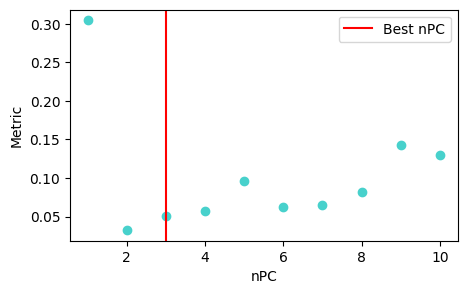

Order 3: best nPC is 3
Order 4: best nPC is 3
Order 5: best nPC is 3
Order 6: best nPC is 3
Order 7: best nPC is 3
Order 8: best nPC is 2
Order 9: best nPC is 2
Order 10: best nPC is 2
Order 11: best nPC is 3
Order 12: best nPC is 2
Order 13: best nPC is 2
Order 14: best nPC is 2
Order 15: best nPC is 2
Order 16: best nPC is 2
Order 17: best nPC is 2
Order 18: best nPC is 2
Order 19: best nPC is 2
Order 20: best nPC is 1
Order 21: best nPC is 2
Order 22: best nPC is 2


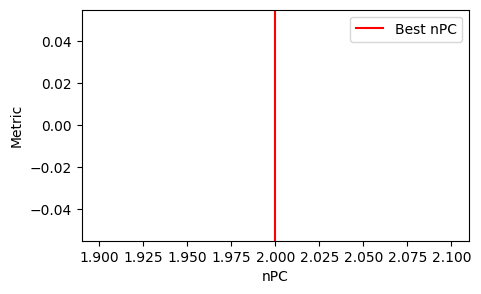

Order 25: best nPC is 3
Order 26: best nPC is 2
Order 27: best nPC is 2
Order 28: best nPC is 2
Order 29: best nPC is 1
Order 30: best nPC is 1
Order 31: best nPC is 1
Order 32: best nPC is 1
Order 33: best nPC is 1
Order 34: best nPC is 1
Order 35: best nPC is 1
Order 36: best nPC is 1
Order 37: best nPC is 2
Order 40: best nPC is 1


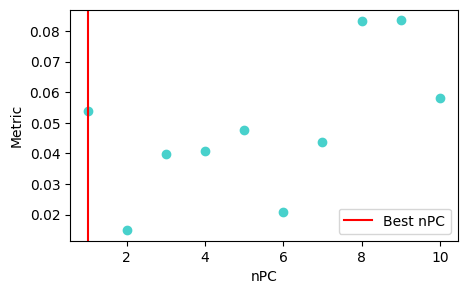

Order 41: best nPC is 1
Order 42: best nPC is 1
Order 43: best nPC is 1
Order 44: best nPC is 1
Order 45: best nPC is 1
Order 46: best nPC is 2
Order 47: best nPC is 3
Order 48: best nPC is 3


In [57]:
# Choose a threshold for the slope of the metric
# When the slope is under that threshold, we consider that the metric plateaus
thresh = 0.1

# Choose orders to plot
order_plot = [2,24,40]
#-----------------------------------------------

best_nPCs = []
deriv_func = FinDiff(0,1)  # derivative function
print("Threshold:", thresh)

for order in range(nb_orders):
    metrics_ord = []
    
    # Get list of metrics for that particular order
    for n_pc in PCs:
        metrics_ord.append(metrics[n_pc - 1][0][order])
    
    deriv_metrics = deriv_func(np.array(metrics_ord))  # find its derivative
    
    # Get best nPC (when metric plateaus)
    for m in deriv_metrics:
        if m < thresh and m > -thresh:
            best_nPC = np.where(deriv_metrics == m)[0][0] + 1
            best_nPCs.append(best_nPC)
            print(f"Order {order}:", "best nPC is", best_nPC)
            break
    
    # Plot (if the order was selected)
    if order in order_plot:
        plt.figure(figsize=(5,3))

        plt.scatter(PCs, metrics_ord, color="mediumturquoise")
        plt.axvline(best_nPC, color="r", label="Best nPC")

        plt.xlabel("nPC")
        plt.ylabel("Metric")

        plt.legend()
        plt.show()



## That's it!

In [10]:
# Verify if every parameter makes sense

print("Mid-transit time (BJD):", "\t", p.mid_tr,
      "\nRadius of the star:", "\t\t", p.R_star.to(u.R_sun),
      "\nRadius of the planet:", "\t\t", p.R_pl.to(u.R_earth),
      "\nObservations in transit:", "\t", obs.iIn,
      "\nObservations out of transit:", "\t", obs.iOut,
      "\nSeparation between planet and star:", "\n", (obs.sep / p.R_star), "R_star"
     )

Mid-transit time (BJD): 	 [2459511.78470659] d 
Radius of the star: 		 [0.121] solRad 
Radius of the planet: 		 [1.127] earthRad 
Observations in transit: 	 [ 7  8  9 10] 
Observations out of transit: 	 [ 0  1  2  3  4  5  6 11 12 13 14 15] 
Separation between planet and star: 
 [4.6137853  4.10056353 3.58483398 3.06720753 2.54814057 2.02852749
 1.50996929 0.99643619 0.50666737 0.27193778 0.66692468 1.16980173
 1.68595717 2.20501708 2.72459452 3.24326052] R_star
